# Session 1 — Introduction to Data Science

> Course notes, reorganized and expanded for clarity. Part of an ongoing series documenting my Data Science coursework.

##  Overview

This session introduces the foundational vocabulary and mental models of Data Science: what the field is, what a Data Scientist actually does day-to-day, how raw data becomes usable information, and the standard process (CRISP-DM) that structures most real-world projects. It closes with a first look at statistics and machine learning as tools within that larger process — not as the process itself.

The thread that ties everything together, repeated twice in the original material, is worth stating up front:

> **Understanding the problem and the data always comes before choosing a solution.**

Every section below builds toward that idea.


---

## 1. What Is Data Science?

Data Science is the discipline of extracting useful knowledge and insight from data. It sits at the intersection of several fields rather than belonging to any single one:

- **Statistics** — for rigorous ways to summarize data and draw conclusions from it
- **Mathematics** — the formal language underlying most methods
- **Programming** — the means of processing data at scale
- **Machine Learning** — algorithms that learn patterns automatically
- **Domain knowledge** — context that makes the numbers meaningful

The goal isn't to apply these techniques for their own sake, but to use data to understand a problem, uncover patterns, make predictions, and ultimately support better decisions.

## 2. What Does a Data Scientist Do?

A Data Scientist combines historical data, statistical reasoning, machine learning, programming, and domain context to investigate problems and build data-driven solutions.

The most easily overlooked part of the job is also the most important: **understanding a problem thoroughly before attempting to solve it.** Jumping straight to modeling without that understanding is one of the most common ways Data Science projects fail.

## 3. Data vs. Information

**Data** is simply a collection of values — numbers, codes, dates — with no inherent meaning attached:

```text
123
M110
1377/04/17
27
```

Take the value `27` in isolation. It could represent an age, a temperature, a test score, or a quantity — there's no way to know. The moment context is attached, the value becomes usable:

```text
Age = 27
```

This is the core distinction: **data is raw; information is data interpreted within a context.** Turning one into the other — through cleaning, structuring, and interpretation — is a large part of what Data Science work actually involves.

| Data       | Context       | Resulting Information    |
|------------|---------------|---------------------------|
| 123        | Student ID    | A student identifier      |
| M110       | Student ID    | A student identifier      |
| 1377/04/17 | Date of birth | A person's date of birth  |
| 27         | Age           | A person's age            |


Therefore, data often needs to be organized, structured, and interpreted so that meaningful information can be extracted from it.

For example, individual values such as:

123
M110
1377/04/17
27

do not provide much meaning on their own.

When these values are organized into a structured dataset, their meaning becomes clearer.

**How is data organized?**

Data can be organized and stored in different structures and formats, such as:

- Flat files
- CSV files
- JSON files
- XML files
- Relational databases

These structures make it possible to store, access, process, and analyze data more effectively.
## 4. Data Sources

Data arrives from a wide range of origins, and the source shapes both the structure and the trustworthiness of what you're working with:

- Databases and business systems
- Flat files (CSV, JSON, XML, TXT)
- Websites and APIs
- Sensors and IoT devices
- Surveys
- External data providers

Knowing *where* data came from is not a formality — it directly affects how much you can trust its quality and how it needs to be cleaned or validated.

## 5. Flat Files and Tabular Data

A **flat file** stores data in a simple structure, without the relational links found in a database. CSV (comma-separated values) is the most common example:

```text
Name,Age,Score
Ali,25,85
Sara,27,91
Reza,24,78
```

This kind of data is **tabular** — organized into rows and columns, where:

- A **row** represents one observation (one person, one transaction, one event)
- A **column** represents one variable or attribute (age, score, name)

A collection of related rows and columns forms a **dataset**.

**Text qualifiers.** When a value itself contains a comma, quotation marks are used to prevent it from being misread as a separator:

```text
Name,Description
Ali,"Data Scientist, Junior"
```

Here, the quotes tell the parser to treat the comma inside the description as part of the text, not as a column boundary.

# Creating and Understanding CSV Datasets

## Working Example

The same file is used throughout this session:

```csv
ID,FirstName,LastName,Education,NationalCode
1,Ali,Rahmani,Master,1230000000
2,Kiana,Zareie,Bachelors,868000000
3,Behnam,Shaygan,Bachelors,87878752
```

---

## Part 1 — Creating a CSV File

One simple way to organize raw data is to arrange it in a **tabular format**: rows and columns instead of an unstructured block of text. Getting there from plain text takes three steps.

### Step 1: Separate the Values with Commas

The data starts as plain text, with each value separated by a comma:

```text
ID,FirstName,LastName,Education,NationalCode
1,Ali,Rahmani,Master,1230000000
2,Kiana,Zareie,Bachelors,868000000
3,Behnam,Shaygan,Bachelors,87878752
```

Each comma marks the boundary between one field and the next. The line

```text
1,Ali,Rahmani,Master,1230000000
```

contains five distinct values: `1`, `Ali`, `Rahmani`, `Master`, and `1230000000`.

### Step 2: Save the File with a `.csv` Extension

The text file is then saved with a `.csv` extension. **CSV** stands for **Comma-Separated Values** — the extension itself doesn't change the underlying data, it just tells software how to interpret the file: as structured data with comma delimiters, rather than as arbitrary text.

### Step 3: Open the File in Spreadsheet Software

When the file is opened in a program like Microsoft Excel, the software reads the commas as column boundaries and renders the values as a table:

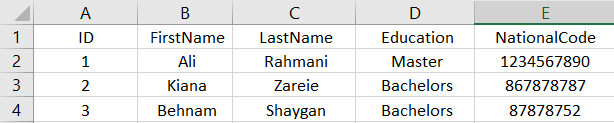
### Why Bother with This Process?

Separating values with commas and saving the result as CSV exists to give raw data **structure**. Instead of an undifferentiated block of text, the data becomes:

- **Rows**, each representing an individual record or observation
- **Columns**, each representing a variable or attribute
- **Commas**, marking the boundary between individual fields

That structure is what allows software — Excel, Python, R, database systems — to read and process the data reliably, rather than treating it as arbitrary text.

### ⚠️ Important Note: Excel Can Silently Change How Values Display

Opening a CSV in Excel doesn't guarantee every value is preserved exactly as stored. Excel may reinterpret certain values automatically. A large number like:

```text
1230000000
```

can be displayed as:

```text
1.23E+09
```

This is **scientific notation**, and it's a common trap when working with identifiers like national codes or phone numbers — Excel treats them as numbers to be simplified rather than as fixed strings. The underlying data in the file hasn't changed, only how Excel *displays* it — but if you re-save from Excel without correcting the column format, the display can become the new stored value. The practical lesson: pay attention not just to a CSV's structure, but to how the software opening it chooses to interpret and show that structure.

---

## Part 2 — The Structure of a CSV Dataset

With the file created, the next step is naming its parts precisely — a distinction that matters throughout the rest of the course.


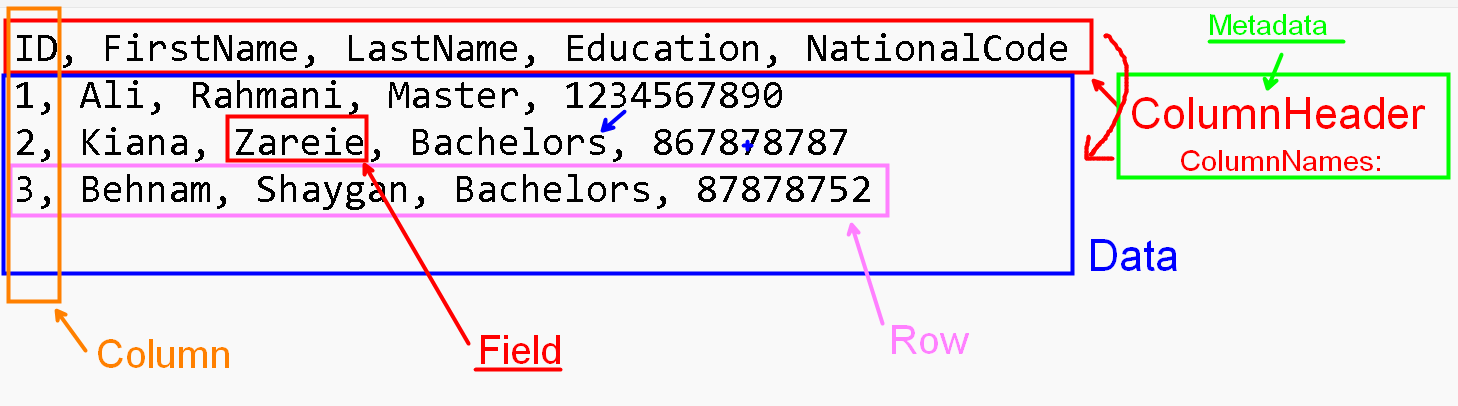
### 1. Column

A **column** represents a single attribute or variable, tracked consistently across every record. `FirstName`, `LastName`, `Education`, and `NationalCode` are each columns — every value under `FirstName` holds the same *kind* of information, even though the specific values differ row to row.

### 2. Column Header

The **column header** is the label naming a column, found in the file's first row:

| Column Header | Meaning |
|---|---|
| ID | Identifier of the record |
| FirstName | First name |
| LastName | Last name |
| Education | Education level |
| NationalCode | National identification code |

Headers are what make a dataset legible. Without them, `1,Ali,Rahmani,Master,1230000000` is just a sequence of values with no indication of what any of them mean.

### 3. Row

A **row** represents one complete record — one observation, describing a single entity. Here, each row describes one person:

```csv
2,Kiana,Zareie,Bachelors,868000000
```

| ID | FirstName | LastName | Education | NationalCode |
|---|---|---|---|---|
| 2 | Kiana | Zareie | Bachelors | 868000000 |

**Row → one record / observation.**

### 4. Field

A **field** is a single value, defined by the intersection of one row and one column. In the row above, `Kiana`, `Zareie`, `Bachelors`, and `868000000` are each individual fields — `Kiana` specifically belongs to row 2, column `FirstName`.

**Field → one value belonging to a particular column in a particular row.**

This is the distinction that's easiest to blur: a *column* is the whole vertical category (`FirstName` across all rows); a *field* is one specific cell within it (`Kiana`, in row 2).

### 5. Data

**Data** refers to the actual stored values — everything beneath the header row:

```csv
1,Ali,Rahmani,Master,1230000000
2,Kiana,Zareie,Bachelors,868000000
3,Behnam,Shaygan,Bachelors,87878752
```

The overall structure looks like this:

```text
                    Dataset
                       │
          ┌────────────┴────────────┐
          │                         │
   Column Headers                 Data
   (ID, FirstName, ...)             │
                          ┌─────────┼─────────┐
                         Row       Row       Row
                          │
                       Fields
```

### 6. Metadata

**Metadata** means *data about data*. Column headers are the clearest example: `FirstName` doesn't itself represent a person's name — it describes what the values beneath it represent. It's a label, not a value.

```text
FirstName   ← metadata (describes the column)
Ali         ← data
Kiana       ← data
Behnam      ← data
```

The `.csv` extension from Part 1 is itself a form of metadata too — it tells software how to interpret the file before a single value is even read. This is the same idea behind a database schema or a data dictionary (Session 1): metadata tells you how to interpret data; it isn't the data itself.

## Terminology Summary

| Term | Meaning | Example |
|---|---|---|
| Dataset | The full collection of organized data | The whole table |
| Column | An attribute / variable | `FirstName` |
| Column Header | The label naming a column | `FirstName` |
| Row | One record / observation | `2,Kiana,Zareie,...` |
| Field | One individual value | `Kiana` |
| Data | The actual stored values | `Kiana`, `Zareie`, `Bachelors` |
| Metadata | Information describing the data | `FirstName`, `.csv` extension |


> **In short: a dataset consists of rows and columns. A row represents a record, a column represents an attribute, and each individual value is a field. Column headers describe the meaning of the columns and count as metadata.**
## 6. Domain Experts and Data Dictionaries

**A Domain Expert** brings specialized knowledge of the field the data comes from — a doctor for healthcare data, a financial analyst for market data, an engineer for manufacturing data. A Data Scientist can understand algorithms perfectly and still misinterpret the data without this input. Domain experts help clarify what variables actually mean, which patterns are meaningful versus coincidental, which values are genuinely unusual, and what a useful solution would even look like.


## 6.1 Domain Expert — Why Raw Values Are Ambiguous

Below is a column of values with no other information attached. Nothing about `0` and `1` is self-explanatory on its own.

In [1]:
import pandas as pd

survived = pd.Series([0, 1, 1, 0, 1], name="Survived")
survived

0    0
1    1
2    1
3    0
4    1
Name: Survived, dtype: int64

Without documentation or domain knowledge, `0` and `1` here could plausibly mean any of the following:

- `0 = Female`, `1 = Male`
- `0 = No`, `1 = Yes`
- `0 = Dead`, `1 = Alive`

Pandas will happily compute a mean or feed this into a model regardless of which interpretation is correct — the numbers alone don't disambiguate.

In [2]:
# Pandas doesn't know or care what these numbers *mean* — it just computes
survived.mean()

np.float64(0.6)

## 6.2 The Titanic Dataset

A small slice of the Titanic dataset illustrates the same ambiguity, at slightly larger scale.

In [3]:
titanic = pd.DataFrame({
    "PassengerId": [1, 2, 3],
    "Survived":    [0, 1, 1],
    "Pclass":      [3, 1, 3],
    "Sex":         ["male", "female", "female"],
    "Age":         [22, 38, 26],
})
titanic

,PassengerId,Survived,Pclass,Sex,Age
0,1,0,3,male,22
1,2,1,1,female,38
2,3,1,3,female,26


### What does `Survived = 1` mean?

Without documentation, this is just an integer. With it, we learn:

- `Survived = 1` → the passenger survived
- `Survived = 0` → the passenger did not survive

That makes `Survived` a **binary** variable — exactly two meaningful states, not an arbitrary number.

In [4]:
survived_labels = {0: "Did not survive", 1: "Survived"}
titanic["Survived_label"] = titanic["Survived"].map(survived_labels)
titanic[["PassengerId", "Survived", "Survived_label"]]

,PassengerId,Survived,Survived_label
0,1,0,Did not survive
1,2,1,Survived
2,3,1,Survived


### What does `Pclass = 1` mean — and why is this the trickier case?

Documentation tells us:

- `Pclass = 1` → First class
- `Pclass = 2` → Second class
- `Pclass = 3` → Third class

The subtle mistake here is treating `Pclass` like an ordinary numeric measurement — the way you'd treat `Age = 20` vs. `Age = 21`. The gap between `Pclass = 1` and `Pclass = 2` isn't a *quantity* the way a one-year age difference is. `Pclass` is **categorical/ordinal**: the classes have a meaningful order, but the numbers encoding them shouldn't be averaged or subtracted as if they were true measurements.

In [5]:
# The mistake: treating Pclass as a plain numeric column
print("Mean of Pclass as a raw number:", titanic["Pclass"].mean())
print("This number has no real-world meaning — 'average passenger class' isn't a meaningful quantity.")

Mean of Pclass as a raw number: 2.3333333333333335
This number has no real-world meaning — 'average passenger class' isn't a meaningful quantity.


In [6]:
# The fix: encode Pclass as an ordered categorical, matching its actual data type
pclass_labels = {1: "First class", 2: "Second class", 3: "Third class"}

titanic["Pclass"] = pd.Categorical(
    titanic["Pclass"].map(pclass_labels),
    categories=["First class", "Second class", "Third class"],
    ordered=True,
)
titanic[["PassengerId", "Pclass"]]

,PassengerId,Pclass
0,1,Third class
1,2,First class
2,3,Third class


In [7]:
# Now pandas knows Pclass is ordered but not numeric —
# operations like .mean() correctly no longer apply
titanic["Pclass"].dtype

CategoricalDtype(categories=['First class', 'Second class', 'Third class'], ordered=True, categories_dtype=object)

## 6.3 Building a Data Dictionary

A Data Dictionary documents what each variable means, its data type, and its valid values — turning the dataset from a table of numbers into something interpretable. It's often just as useful represented as data itself.

In [8]:
data_dictionary = pd.DataFrame([
    {"Variable": "PassengerId", "Data Type": "Integer",             "Description": "Unique passenger identifier",     "Possible Values": "Unique numbers"},
    {"Variable": "Survived",    "Data Type": "Binary",              "Description": "Whether the passenger survived",  "Possible Values": "0 = No, 1 = Yes"},
    {"Variable": "Pclass",      "Data Type": "Categorical/Ordinal", "Description": "Passenger class",                 "Possible Values": "1, 2, 3"},
    {"Variable": "Name",        "Data Type": "Text",                "Description": "Passenger's name",                "Possible Values": "Text"},
    {"Variable": "Sex",         "Data Type": "Categorical",         "Description": "Passenger's sex",                 "Possible Values": "Male, Female"},
    {"Variable": "Age",         "Data Type": "Numeric",             "Description": "Passenger's age",                 "Possible Values": "Non-negative values"},
    {"Variable": "SibSp",       "Data Type": "Integer",             "Description": "Number of siblings/spouses aboard","Possible Values": "0 or greater"},
    {"Variable": "Parch",       "Data Type": "Integer",             "Description": "Number of parents/children aboard","Possible Values": "0 or greater"},
    {"Variable": "Fare",        "Data Type": "Numeric",             "Description": "Passenger fare",                  "Possible Values": "Non-negative values"},
])
data_dictionary

,Variable,Data Type,Description,Possible Values
0,PassengerId,Integer,Unique passenger identifier,Unique numbers
1,Survived,Binary,Whether the passenger survived,"0 = No, 1 = Yes"
2,Pclass,Categorical/Ordinal,Passenger class,"1, 2, 3"
3,Name,Text,Passenger's name,Text
4,Sex,Categorical,Passenger's sex,"Male, Female"
5,Age,Numeric,Passenger's age,Non-negative values
6,SibSp,Integer,Number of siblings/spouses aboard,0 or greater
7,Parch,Integer,Number of parents/children aboard,0 or greater
8,Fare,Numeric,Passenger fare,Non-negative values


### 6.4 Domain Expert vs. Data Dictionary

| | Domain Expert | Data Dictionary |
|---|---|---|
| Source | Human expertise, real-world knowledge | Written documentation |
| Provides | Meaning and context, often undocumented | Variable definitions, types, valid values, units, missing-value conventions |
| Limitation | Can't be consulted for every value in a large dataset | Can go stale or be incomplete |

Both feed into the same pipeline:

```
Data → Domain Expert + Data Dictionary → Understanding the Data → Analysis → Modeling
```

**Key idea:** never infer the meaning of a variable from its values alone. As this notebook showed, `0`, `1`, `2`, and `3` in the Titanic dataset are just numbers until domain knowledge and documentation say what they stand for — and getting that step wrong (as with treating `Pclass` as numeric) can quietly distort an entire analysis before it even begins.


## 7. Data Quality

Poor-quality data leads to unreliable analysis, no matter how sophisticated the modeling technique. Four concepts are central to assessing quality:

**Missing Data** — values that were never recorded or are unavailable. Most statistical and machine learning methods require an explicit strategy for handling these rather than ignoring them.

**Range** — the plausible minimum and maximum for a variable (e.g., `0 ≤ Age ≤ 120`). Range checks are a quick way to catch clearly invalid entries.

## Outlier vs. Noise

These two concepts are often confused, but they describe fundamentally different things.

**Outlier** — an observation that is unusual, but still plausible. It deviates from the general pattern of the data, yet it can still be a genuine, correctly recorded value. Consider the ages `21, 22, 23, 24, 25, 26, 78`. The value `78` is far from the rest — but a 78-year-old person is entirely possible. This is why an outlier should be investigated, not automatically deleted: it might be a data-entry mistake, or it might be a real and informative data point.

**Noise** — unwanted, random variation that carries no meaningful signal. Unlike an outlier, noise isn't just unusual — it's often **implausible**: a value that couldn't reasonably occur in the real world at all (e.g., `Age = -5`, or `Age = 400`). Noise doesn't reflect a real pattern; it obscures the true pattern underneath it.

### The Key Distinction

| | Unusual? | Plausible? |
|---|---|---|
| **Outlier** | Yes | Yes — could genuinely occur |
| **Noise** | Yes | No — physically or logically impossible |

> **An outlier is unusual but credible. Noise is unusual and incredible.**

That's the line that separates them: an outlier challenges your assumptions about what's *typical*; noise challenges your assumptions about what's *possible*. Treating a real outlier as noise (and deleting it) throws away genuine information. Treating noise as an outlier (and keeping it) lets corrupted data distort your analysis.

# 8. Importing Data into Power Query (Excel)

> Course notes, reorganized and expanded for clarity. Part of an ongoing series documenting my Data Science coursework.

## 8.1  why?

Once a dataset lives inside Excel, the next problem is cleaning and reshaping it before it's ready for analysis. Excel's **Power Query** is the tool built for exactly that. This session covers how to get a table from a plain Excel range into Power Query, what happens once you're there, and why the professor used this exact workflow to prepare the Titanic dataset for analysis.


## 8.2 The Starting Point: A Plain Excel Range

Suppose your worksheet contains a simple dataset:

| Name | Age | Salary |
|---|---|---|
| Ali | 25 | 3000 |
| Sara | 28 | 3500 |
| Reza | 31 | 4200 |

At this point, it's just a range of cells — Excel doesn't yet treat it as a structured "table" with defined columns and behaviors of its own.

## 8.3 Step-by-Step: From Table/Range → Power Query

### Step 1: Select the Dataset

Click anywhere inside the data range (you don't need to manually select every cell — Excel detects the surrounding block automatically).

### Step 2: Go to `Data → From Table/Range`

This tells Excel: *take this range and hand it over to Power Query so it can be cleaned and transformed.*
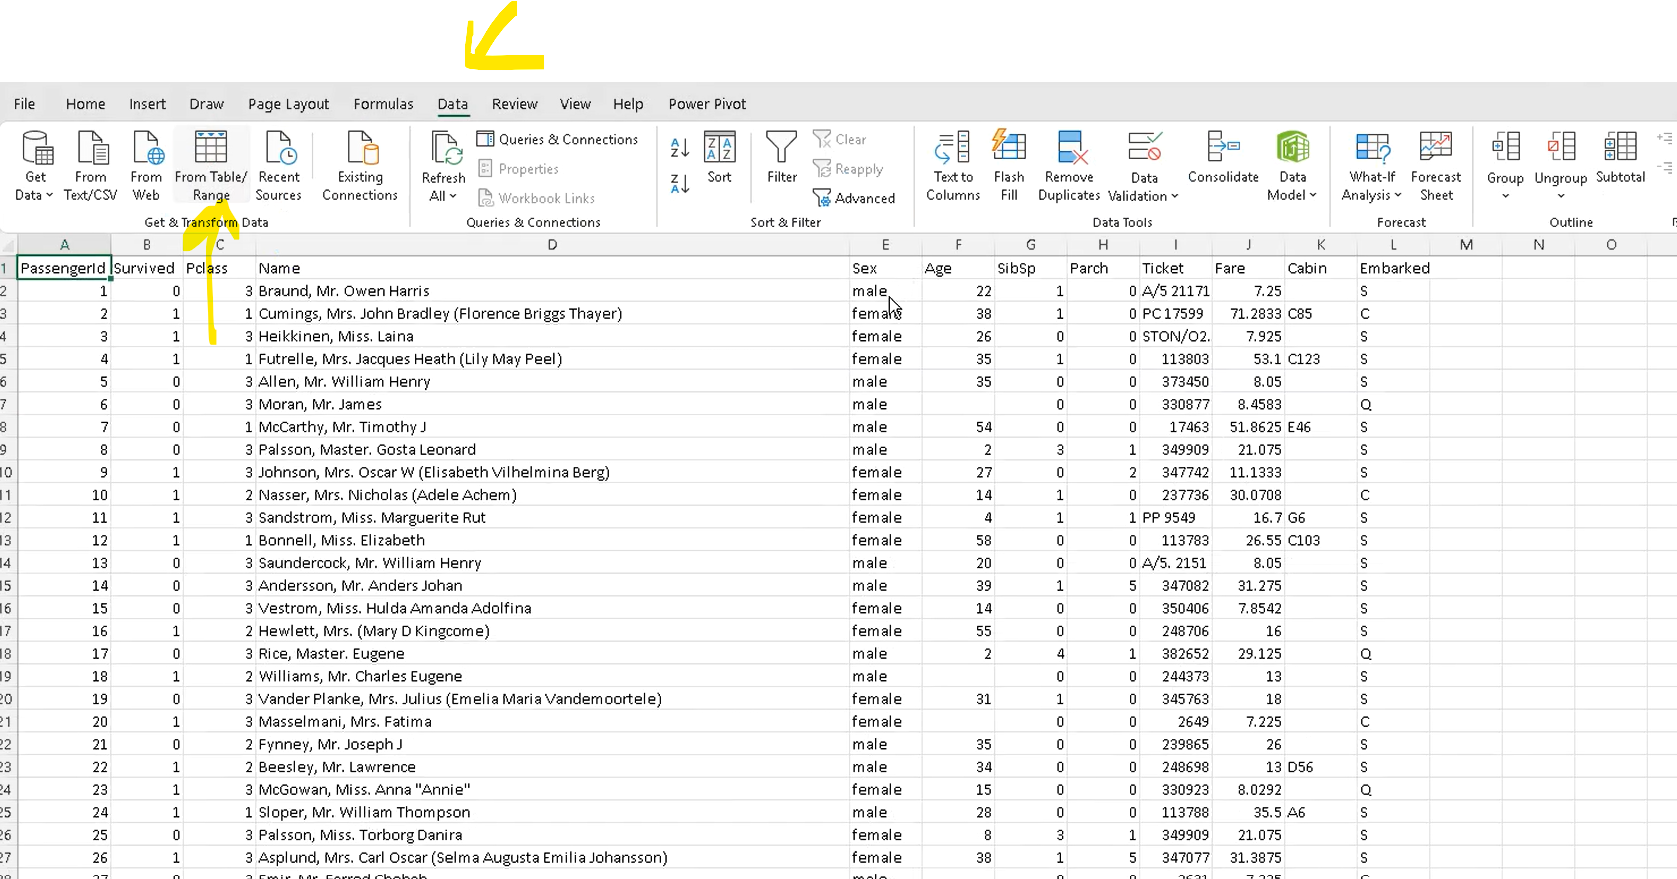

### Step 3: Confirm the Range, and Check "My Table Has Headers"

A dialog box appears asking you to confirm the selected range. This is where the **"My table has headers"** checkbox matters:

- **If checked** → Excel treats the first row (`Name, Age, Salary`) as **column headers**, not as data. This is almost always what you want when your first row contains labels rather than actual values.
- **If left unchecked** → Excel assumes there is no header row, and generates generic names (`Column1`, `Column2`, `Column3`) instead — while your real header row (`Name, Age, Salary`) gets treated as if it were a normal data row, which is almost never correct.

So in practice: **if your first row contains column names, always leave this checked.**
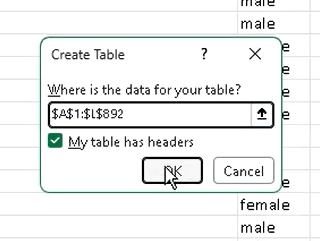

### Step 4: The Power Query Editor Opens

Confirming the dialog opens an entirely separate environment: the **Power Query Editor**. This is a different window from the regular Excel worksheet — it has its own ribbon, its own data preview, and its own step-by-step history. This separation is intentional: Power Query is a workspace for *transforming* data, distinct from the worksheet where you *view and use* it.

## 8.4 What You Can Actually Do Inside Power Query

Power Query exists specifically to prepare and clean data before analysis. Typical operations include:

- Removing a column entirely
- Renaming a column
- Changing a column's data type (e.g., Text → Number)
- Removing empty rows
- Removing duplicate rows
- Keeping only certain rows (filtering)
- Splitting one column into several
- Merging two columns into one

### 8.5 A Concrete Example: Removing Duplicates

Take this raw data, which contains an accidental duplicate row:

| Name | Age | Salary |
|---|---|---|
| Ali | 25 | 3000 |
| Sara | 28 | 3500 |
| Ali | 25 | 3000 |

Inside Power Query, choosing **Remove Duplicates** collapses it to:

| Name | Age | Salary |
|---|---|---|
| Ali | 25 | 3000 |
| Sara | 28 | 3500 |

## 8.6 The Important Part: Power Query Doesn't Touch Your Original Data

Power Query generally does **not** modify the source data directly. Instead, every action you take is recorded as an **Applied Step**, building a visible, ordered pipeline:

```text
Source
  ↓
Changed Type
  ↓
Removed Duplicates
  ↓
Filtered Rows
  ↓
Removed Columns
```

This has a very practical benefit: if you later load a *new* dataset with the same structure, you can simply hit **Refresh**, and Power Query re-runs the exact same sequence of steps automatically — no need to repeat the cleaning process by hand.


## 8.7 What You Can Do Inside Power Query — A Fuller Picture

Power Query's toolset maps almost directly onto the **Data Preparation** stage of CRISP-DM (Session 1). Below is a more complete breakdown, organized by category, of what's actually available and why each capability matters for data science work specifically.

### 1. Structural Operations 

| Action | What It Does | Why It Matters for Data Science |
|---|---|---|
| **Remove Columns** | Deletes columns you don't need | Keeps only relevant features before analysis; reduces noise |
| **Keep Columns** | Inverse of the above — keeps only selected columns | Faster than removing many columns one by one |
| **Rename Columns** | Changes column headers | Produces clear, consistent variable names (matches Data Dictionary conventions) |
| **Reorder Columns** | Changes column order | Purely cosmetic, but improves readability |
| **Split Column** | Breaks one column into several (by delimiter, position, etc.) | E.g., splitting `FullName` into `FirstName` / `LastName`, or a date into `Year`/`Month`/`Day` |
| **Merge Columns** | Combines multiple columns into one | E.g., combining `FirstName` + `LastName` into `FullName` |
| **Transpose** | Swaps rows and columns | Useful when data was entered "sideways" relative to how you need it |
| **Pivot / Unpivot Columns** | Reshapes data between wide and long formats | Long format is usually what statistical and ML tools expect |

### 2. Data Type & Formatting

| Action | What It Does | Why It Matters for Data Science |
|---|---|---|
| **Change Data Type** | Converts a column (e.g., Text → Number, Text → Date) | A column stored as text can't be averaged, filtered numerically, or modeled correctly |
| **Detect Data Type** | Automatically infers the type of each column | Quick first pass, but should always be manually verified (see Session 3's `Pclass` lesson — numeric-looking values aren't always numeric in meaning) |
| **Trim / Clean** | Removes extra spaces or non-printable characters | Prevents `"Ali"` and `"Ali "` from being treated as different categories |
| **Format Text** (uppercase/lowercase/capitalize) | Standardizes text casing | Prevents `"male"` and `"Male"` from being counted as separate categories |

### 3. Row-Level Filtering & Cleaning

| Action | What It Does | Why It Matters for Data Science |
|---|---|---|
| **Remove Duplicates** | Deletes exact duplicate rows | Duplicate records inflate counts and bias statistics |
| **Remove Blank Rows** | Deletes entirely empty rows | Cleans up artifacts from manual data entry |
| **Filter Rows** | Keeps only rows matching a condition | E.g., keep only passengers where `Age` is not null, or `Pclass = 1` |
| **Remove Errors** | Drops rows where a transformation failed (e.g., a value couldn't convert to a number) | Prevents corrupted rows from silently entering the dataset |
| **Sort Rows** | Orders rows by one or more columns | Helps visually inspect data — e.g., sorting by `Age` to spot implausible values (Session on Outliers vs. Noise) |

### 4. Handling Missing Values

| Action | What It Does | Why It Matters for Data Science |
|---|---|---|
| **Replace Values** | Substitutes one value for another (e.g., blank → 0, or "N/A" → null) | Standardizes how missing data is represented, tying directly into Session 1's "Missing Data" concept |
| **Fill Down / Fill Up** | Propagates the last non-empty value into blank cells below/above | Common in exported reports where a category is only written once and left blank for repeated rows |

### 5. Combining Data From Multiple Sources

| Action | What It Does | Why It Matters for Data Science |
|---|---|---|
| **Append Queries** | Stacks two tables with the same columns on top of each other | Combining monthly files into one yearly dataset |
| **Merge Queries** | Joins two tables based on a shared key (like a SQL join) | E.g., joining a `Passengers` table with a `Fares` table on `PassengerId` — directly mirrors the Relational Database concept from Session 1 |

### 6. Calculated / Derived Columns

| Action | What It Does | Why It Matters for Data Science |
|---|---|---|
| **Add Custom Column** | Creates a new column from a formula referencing other columns | E.g., deriving `AgeGroup` from `Age`, or `FarePerPerson` from `Fare` and `FamilySize` |
| **Conditional Column** | Creates a new column based on if/then logic | E.g., creating a `Survived_label` column that turns `0/1` into `"Died"/"Survived"` — directly the kind of decoding covered in the Domain Expert & Data Dictionary session |
| **Group By** | Aggregates rows (sum, average, count, etc.) by category | E.g., average `Fare` per `Pclass` — an early step toward Descriptive Statistics (Session 1) |

## 8.8 How This All Fits Together

Every one of these operations becomes an **Applied Step**, so a typical Power Query pipeline for a dataset like Titanic might look like:

```text
Source
  ↓
Changed Type            (Age → Number, Fare → Decimal)
  ↓
Removed Duplicates
  ↓
Replaced Value           (blank Age → null, marked explicitly as missing)
  ↓
Filtered Rows            (removed rows with no PassengerId)
  ↓
Added Conditional Column (Survived → "Survived"/"Died")
  ↓
Removed Columns          (dropped irrelevant fields, e.g. Cabin if mostly empty)
```

##  Notice

Power Query isn't just a cleanup tool — it's essentially a no-code implementation of the **Data Understanding → Data Preparation** stages of CRISP-DM. Nearly every concept introduced earlier in this course (missing data, data types, data dictionaries, duplicates, relational joins) has a direct, clickable counterpart inside Power Query. Learning this tool well means you can perform a large share of a data science project's preparation work before ever opening Python or R.

# 8.9 Power Query — Complete Guide to the View Tab

This is the full reference version, covering every feature in the View tab from the beginning, with special depth on **Column Statistics** and **Value Distribution** — the two areas you asked to go through completely.
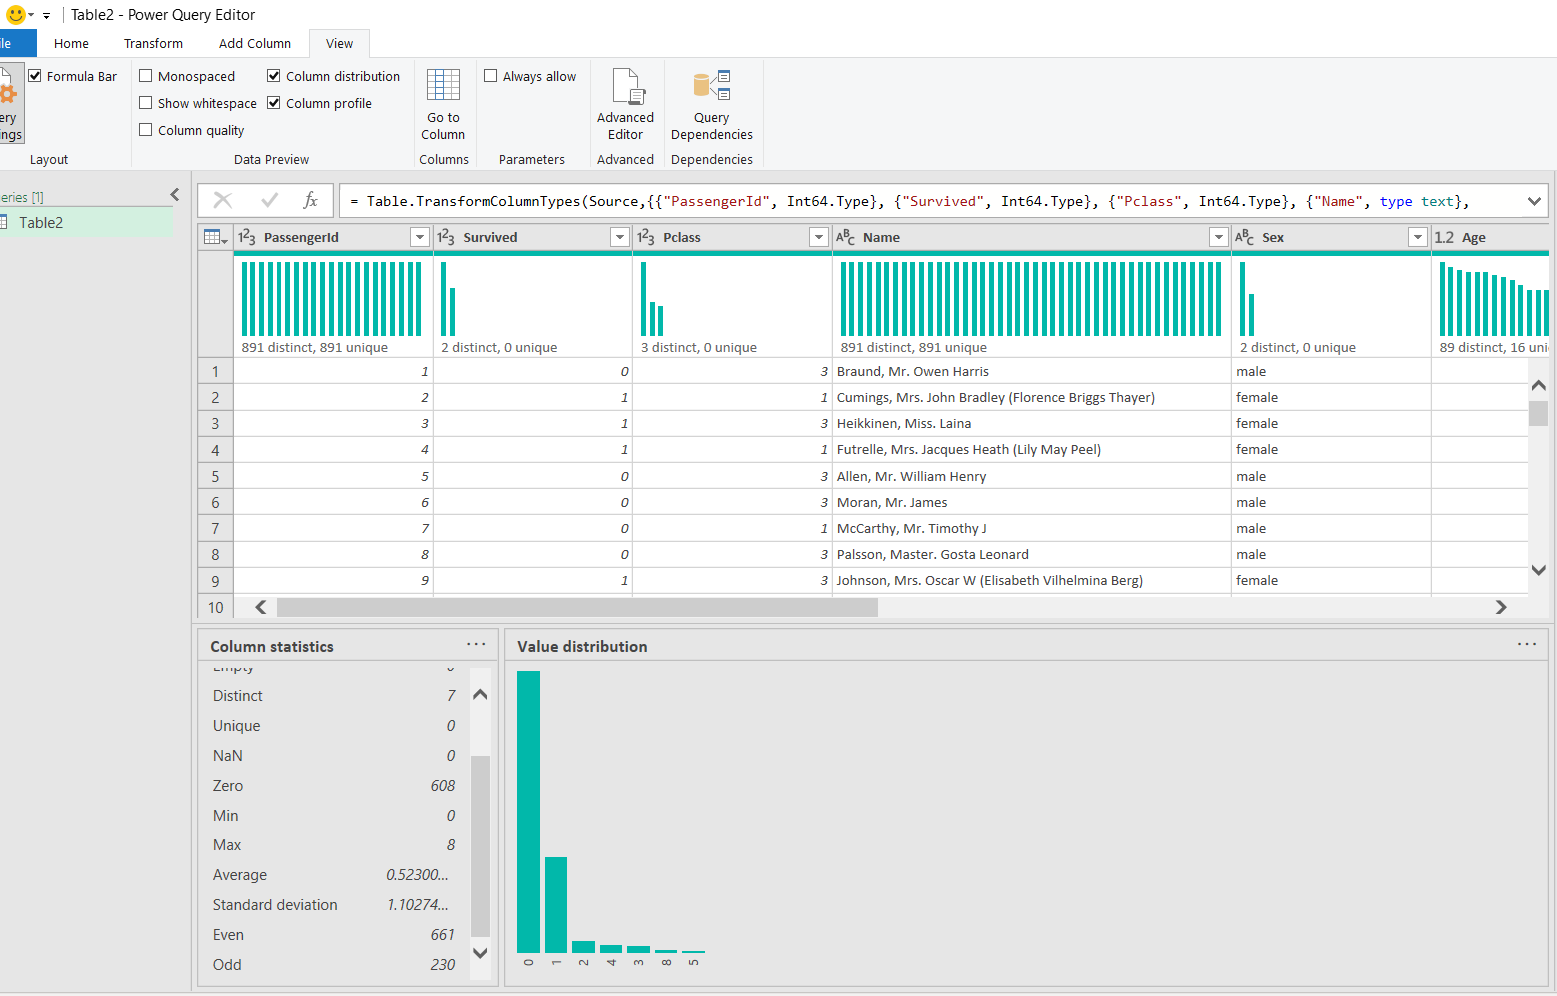

## The View Tab: Full Layout

The View tab is organized into four groups. Here's the complete map before going into each one in depth:

| Group | Contains |
|---|---|
| **Preview** | Formula Bar · Column Quality · Column Distribution · Column Profile |
| **Layout** | Query Settings pane |
| **Data Preview** | "Always allow..." toggle · Profiling scope (1,000 rows vs. entire dataset) |
| **Advanced** | Advanced Editor · Diagnostics |

---

## 1. Formula Bar

A thin text bar just above the data preview, showing the M code for whatever step is currently selected in Applied Steps.

- Every UI action (rename, filter, remove duplicates, change type) is really just a line of M code being generated behind the scenes.
- The Formula Bar shows that line for the currently selected step only — not the whole query.
- You can edit it directly here for small tweaks, without opening the full Advanced Editor.

**Example:** selecting the "Removed Duplicates" step shows something like:
```
= Table.Distinct(Source)
```

## 2. Column Quality

A small colored bar under each column header, split into three segments:

| Segment | Color | Meaning |
|---|---|---|
| Valid | Green | Percentage of well-formed, usable values |
| Error | Red | Percentage of values that failed a transformation |
| Empty | Gray | Percentage of missing/null values |

Clicking on any segment filters the column preview to show only rows matching that condition (e.g., clicking "Error" shows just the rows with errors) — useful for jumping straight to the problem rows instead of scrolling to find them.

## 3. Column Distribution

A small bar chart under each column header showing the frequency of values, plus two summary numbers shown on hover:

- **Distinct count** — how many different values appear in the column, each counted once regardless of repetition
- **Unique count** — how many values appear *exactly once* in the whole column

Right-clicking the chart gives quick actions, including jumping directly to **Group By** on that column, or copying the underlying distribution data.

## 4. Column Profile — Full Detail

This is the deepest of the four Preview tools. Clicking a column opens a dedicated panel below the preview, split into two halves: **Column Statistics** (numbers) on the left, and **Value Distribution** (a chart) on the right.

### 4a. Column Statistics — Every Option Explained

| Statistic | What It Measures | How to Read It |
|---|---|---|
| **Count** | Total number of values in the column, including empty and error values | Should match the total row count of the table |
| **Error** | Number of values that failed a transformation (e.g., text that wouldn't convert to Number) | Any non-zero value here means something in that column doesn't match its assigned data type |
| **Empty** | Number of null/blank values | The raw count behind the gray segment in Column Quality — useful on large datasets where percentages hide the real scale of the problem |
| **Distinct** | Number of different values in the column | For an ID column, this should equal Count. For a category column (e.g., `Sex`), this should be a small number (2, in that case) |
| **Unique** | Number of values that occur exactly once | High Unique relative to Count suggests the column behaves more like an identifier than a category |
| **NaN** | (For numeric columns) count of "Not a Number" results — values that are technically numeric-type but invalid (e.g., a division by zero somewhere upstream) | Distinct from Empty: a NaN is a numeric placeholder for an invalid calculation, not a missing value |
| **Zero** | Count of values equal to 0 | Useful to check whether 0 is being used as a real value or as a stand-in for missing data — an important distinction (Session 1's Missing Data concept) |
| **Min** | The smallest value in the column | For `Age`, a Min below 0 is not an outlier — it's impossible, i.e., **Noise** |
| **Max** | The largest value in the column | For `Age`, a Max like 300 is similarly implausible — again Noise, not a genuine Outlier |
| **Average** | The arithmetic mean of the column | Compare against domain expectations — a wildly off Average often signals a unit mismatch (e.g., Fare recorded in cents instead of currency units) |
| **Standard deviation** | How spread out the values are around the Average | A very large standard deviation often means a small number of extreme values are pulling it up — worth checking the Value Distribution chart next to confirm |

**Note:** which statistics appear depends on the column's data type. Text columns show Count/Error/Empty/Distinct/Unique. Numeric and date columns additionally show Min/Max/Average/Standard Deviation/Zero/NaN, since those calculations only make sense for numbers and dates.

### 4b. Value Distribution — Full Detail

The **Value Distribution** panel is the visual counterpart to Column Statistics — a larger, more detailed version of the small bar chart from Column Distribution.

**What it shows, depending on column type:**

- **Categorical/text columns** — a bar for each distinct value, height proportional to how often it occurs. Sorting is typically by frequency, so the most common categories appear first. This is where you'd immediately notice inconsistent categories that should be one value but got split by inconsistent spelling or casing — e.g., `"male"`, `"Male"`, `"MALE"` showing as three separate bars instead of one.

- **Numeric columns** — values are grouped into ranges (bins), and the chart shows how many values fall into each bin, forming a shape similar to a histogram. This is precisely how you visually spot an **Outlier** (a lone bar far off to the side, but still a plausible value) versus **Noise** (a value sitting somewhere the axis shouldn't even reasonably extend to, like a negative age).

**Interactions available directly on the chart:**

- **Hovering** over any bar shows the exact value (or range) and its count
- **Right-clicking** a bar gives direct actions:
  - **Equals / Does Not Equal** — instantly filters the whole table to rows matching (or excluding) that specific value
  - **Copy** — copies that value or the whole distribution
- This means the Value Distribution chart isn't just for looking — it's a shortcut into filtering, without needing to open the Filter dropdown on the column header separately

**Why this view matters more than it might first seem:** for a categorical column, the distribution chart often reveals **data entry inconsistency** before Column Statistics does — the Distinct count might report "5 categories" when really there are only 3 real categories, with 2 of them being typos or casing variants of the others. Column Statistics tells you *how many* distinct values exist; Value Distribution shows you *which* ones and whether that count actually makes sense.

## 5. Query Settings Pane

Docked on the right side by default, with two sections:

- **Properties** — the query's name (this becomes the table name once loaded into Excel) and an optional description
- **Applied Steps** — the ordered, clickable list of every transformation performed so far (`Source → Changed Type → Removed Duplicates → ...`)

Each step here is interactive:
- **Click** a step to preview the data exactly as it was at that point in the pipeline
- **Right-click** to rename, delete, or move a step
- The **gear icon** next to certain steps reopens that step's settings dialog for editing (e.g., reopening "Changed Type" to adjust which columns were affected)

## 6. Data Preview Group — Profiling Scope

Two related settings:

- **"Always allow interaction with data preview to trigger data profiling"** — a toggle controlling whether opening a column automatically calculates its profile, or whether you need to trigger it manually (relevant for very large datasets, where automatic profiling on every click can slow things down)
- **Column profiling based on top 1,000 rows / entire dataset** — shown as text at the bottom-left status bar, and clickable to switch. This directly controls whether everything discussed above (Column Quality, Distribution, Profile, Statistics) is calculated from a 1,000-row sample or the full table. For any dataset larger than 1,000 rows, switching to full-dataset profiling before making final cleaning decisions is important — a column can look completely clean in a partial sample while hiding problems further down.

